# Training

In [1]:
import os

In [2]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [3]:
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import torch.nn as nn
import torch.nn.functional as F

from DCLS.construct.modules import Dcls3_1d
from torch.cuda import amp
from spikingjelly.activation_based import functional, surrogate, neuron, layer
from spikingjelly.activation_based.model import parametric_lif_net
from spikingjelly.datasets.dvs128_gesture import DVS128Gesture
from spikingjelly.datasets.dvs_lip import DVSLip
from torch.utils.data import DataLoader
import time
import os
import argparse
import datetime

In [4]:
T = 16
b = 128
j = 8
lr = 0.01
epochs = 100

channels = 16
kernel_size = 3
max_delay = 7

number_of_classes = 11

dataset_class = DVS128Gesture

data_dir = os.path.expanduser('~/datasets/DVSGesture/')

In [5]:
device = 'cuda:0'

In [6]:
class Dcls3_1_SJ(Dcls3_1d):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_count,
        learn_delay=True,
        stride=1,
        spatial_padding=0,
        dense_kernel_size=1,
        dilated_kernel_size=1,
        groups=1,
        bias=True,
        padding_mode='zeros',
        version='gauss',
    ):
        super().__init__(
            in_channels,
            out_channels,
            kernel_count,
            stride,
            (*spatial_padding, 0),
            dense_kernel_size,
            dilated_kernel_size,
            groups,
            bias,
            padding_mode,  
            version,
        )
        self.learn_delay = learn_delay
        self.dilated_kernel_size = dilated_kernel_size
        if not self.learn_delay:
            # torch.nn.init.constant_(self.P, dilated_kernel_size // 2)
            self.P.requires_grad = False

    def forward(self, x):
        x = x.permute(1, 2, 3, 4, 0) # [T, N, C, H, W] -> [N, C, H, W, T]
        x = F.pad(x, (self.dilated_kernel_size-1, 0), mode='constant', value=0)
        x = super().forward(x)
        x = x.permute(4, 0, 1, 2, 3) # [N, C, H, W, T] -> [T, N, C, H, W]
        return x

In [7]:
class DVSNet(nn.Module):
    def __init__(self,
                 channels=channels,
                 spiking_neuron: callable=None,
                 delayed=False,
                 learn_delay=False,
                 kernel_size=kernel_size,
                 max_delay=max_delay,
                 **kwargs):
        super().__init__()

        conv = []
        ## Stem
        conv.append(layer.Conv2d(2, channels, kernel_size=2, stride=2, 
                                    bias=False))
        conv.append(layer.BatchNorm2d(channels))

        ## Middle Layers
        for i in range(4):
            if delayed:
                version = 'gauss' if learn_delay else 'v1'
                conv.append(
                    Dcls3_1_SJ(in_channels=channels, out_channels=channels, kernel_count=1,
                               learn_delay=learn_delay, dense_kernel_size=kernel_size, dilated_kernel_size=max_delay,
                               bias=False, groups=channels, spatial_padding=(kernel_size//2, kernel_size//2), version=version
                              )        
                )
            else:
                conv.append(layer.Conv2d(channels, channels,
                                         kernel_size=kernel_size, groups=channels,
                                         padding='same', bias=False)
                )
            conv.append(layer.Conv2d(channels, channels, kernel_size=1))
            conv.append(layer.BatchNorm2d(channels))    
            conv.append(spiking_neuron(**deepcopy(kwargs)))
            if i != 3:
                conv.append(layer.Conv2d(channels, 2*channels, kernel_size=2, bias=False, stride=2))
                channels = channels * 2
        

        self.conv = nn.Sequential(
            *conv, 
            layer.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = layer.Linear(in_features=channels, out_features=number_of_classes)
        
    def forward(self, x: torch.Tensor):
        x = self.conv(x).mean((3, 4))
        x = self.fc(x)
            
        return x


In [8]:
train_set = dataset_class(root=data_dir, train=True, data_type='frame', frames_number=T, split_by='number')
test_set = dataset_class(root=data_dir, train=False, data_type='frame', frames_number=T, split_by='number')

The directory [/home/tahaf/datasets/DVSGesture/frames_number_16_split_by_number] already exists.
The directory [/home/tahaf/datasets/DVSGesture/frames_number_16_split_by_number] already exists.


In [9]:
train_data_loader = torch.utils.data.DataLoader(
    dataset=train_set,
    batch_size=b,
    shuffle=True,
    drop_last=True,
    num_workers=j,
    pin_memory=True
)

test_data_loader = torch.utils.data.DataLoader(
    dataset=test_set,
    batch_size=b,
    shuffle=True,
    drop_last=False,
    num_workers=j,
    pin_memory=True
)

In [10]:
scaler = amp.GradScaler()

In [11]:
num_trials = 10
seeds = np.random.randint(1000, size=num_trials)

In [12]:
def check_model(kernel_size, channels, delayed, seed):
    train_accs = []
    test_accs = []
    train_losses = []
    test_losses = []
    # max_test_acc = -1
    # min_train_loss = float('inf')

    net = DVSNet(
        channels=channels,
        kernel_size=kernel_size,
        spiking_neuron=neuron.LIFNode,
        surrogate_function=surrogate.ATan(),
        delayed=delayed,
        detach_reset=True
    )
    
    net.to(device)
    num_params = sum(p.numel() for p in net.parameters())
    functional.set_step_mode(net, step_mode='m')

    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, total_steps=round(epochs*len(train_set)/b), max_lr=lr)
    
    start_time = time.time()
    for epoch in range(epochs):
        print(f'Epoch {epoch}')
        net.train()
        train_loss = 0
        train_acc = 0
        train_samples = 0
        t1 = time.time()
        for frame, label in train_data_loader:
            optimizer.zero_grad()
            frame = frame.to(device)
            frame = frame.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
            label = label.to(device)
            label_onehot = F.one_hot(label, number_of_classes).float()
    
            if scaler is not None:
                with amp.autocast():
                    out_fr = net(frame)
                    loss = functional.temporal_efficient_training_cross_entropy(out_fr, label)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                out_fr = net(frame)
                loss = functional.temporal_efficient_training_cross_entropy(out_fr, label)
                loss.backward()
                optimizer.step()
    
            train_samples += label.numel()
            train_loss += loss.item() * label.numel()
            train_acc += (out_fr.mean(0).argmax(1) == label).float().sum().item()
    
            functional.reset_net(net)
    
        train_loss /= train_samples
        train_acc /= train_samples

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # writer.add_scalar(f'seed_{seed}/loss/train_delayed_{delayed}', train_loss, epoch)
        # writer.add_scalar(f'seed_{seed}/accuracy/train_delayed_{delayed}', train_acc, epoch)

        # min_train_loss = min(min_train_loss, train_loss)
    
        lr_scheduler.step()
    
        net.eval()
        test_loss = 0
        test_acc = 0
        test_samples = 0
        with torch.no_grad():
            for frame, label in test_data_loader:
                frame = frame.to(device)
                frame = frame.transpose(0, 1)  # [N, T, C, H, W] -> [T, N, C, H, W]
                label = label.to(device)
                label_onehot = F.one_hot(label, number_of_classes).float()
                out_fr = net(frame)
                loss = functional.temporal_efficient_training_cross_entropy(out_fr, label)
                test_samples += label.numel()
                test_loss += loss.item() * label.numel()
                test_acc += (out_fr.mean(0).argmax(1) == label).float().sum().item()
                functional.reset_net(net)
        test_loss /= test_samples
        test_acc /= test_samples

        test_losses.append(test_loss)
        test_accs.append(test_acc)

        # writer.add_scalar(f'seed_{seed}/loss/test_delayed_{delayed}', test_loss, epoch)
        # writer.add_scalar(f'seed_{seed}/accuracy/test_delayed_{delayed}', test_acc, epoch)
        
        # max_test_acc = max(max_test_acc, test_acc)
        t2 = time.time()
        
    end_time = time.time()
    total_time = end_time - start_time
    print(f'total time: {total_time}s')
    print('-'*1000)

    return {
        'accuracy': {
            'train': train_accs,
            'test': test_accs,
        },
        'loss': {
            'train': train_losses,
            'test': test_losses,
        },
        'total_time': total_time,
        'num_params': num_params,
    }

In [13]:
def check_models(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    result1 = check_model(channels=16, kernel_size=5, delayed=False, seed=seed)
    result2 = check_model(channels=16, kernel_size=5, delayed=True, seed=seed)

    return result1, result2

In [14]:
results1 = []
results2 = []

In [ ]:
for i in range(len(seeds)):
    print(f'Round {i+1}')
    result1, result2 = check_models(seeds[i])
    results1.append(result1)
    results2.append(result2)

Round 1
Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50


In [16]:
seeds

array([303, 163, 111, 930, 572, 282, 513, 768,  69, 168])

# Viualization

In [17]:
def get_stats(raw_stats):
  mean = np.mean(raw_stats, axis=0)
  std = np.std(raw_stats, axis=0)
  upper_bound = mean + 1.96 * std / np.sqrt(len(raw_stats))
  lower_bound = mean - 1.96 * std / np.sqrt(len(raw_stats))

  return mean, upper_bound, lower_bound

In [18]:
def compare(results1, results2, stat, train_or_test):
    first = [result[stat][train_or_test] for result in results1]
    second = [result[stat][train_or_test] for result in results2]

    first_mean, first_upper_bound, first_lower_bound = get_stats(first)
    second_mean, second_upper_bound, second_lower_bound = get_stats(second)
    
    
    fig, ax = plt.subplots()
    
    ax.plot(first_mean, label='Without Delay')
    ax.fill_between(np.arange(len(first_mean)), first_lower_bound, first_upper_bound , alpha=0.5)
    
    ax.plot(second_mean, label='With Delay')
    ax.fill_between(np.arange(len(second_mean)), second_lower_bound, second_upper_bound , alpha=0.5)
    
    ax.set_title(f'{stat} - {train_or_test}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'{stat}')
    plt.legend()
    plt.show()

## Accuracy

### Train

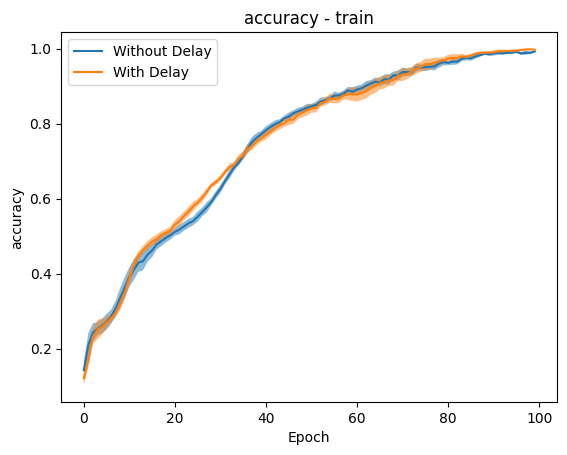

In [19]:
compare(results1, results2, 'accuracy', 'train')

### Test

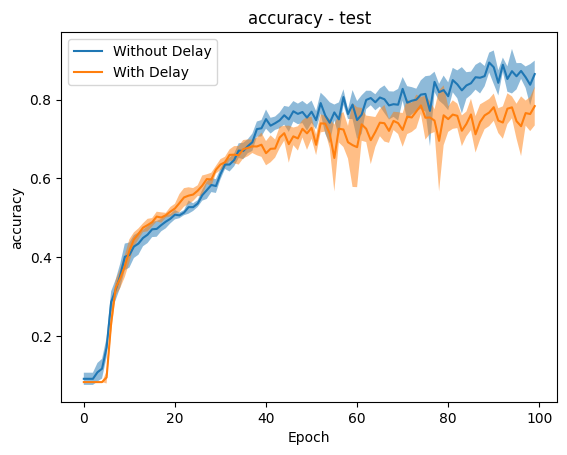

In [20]:
compare(results1, results2, 'accuracy', 'test')

## Loss

### Train

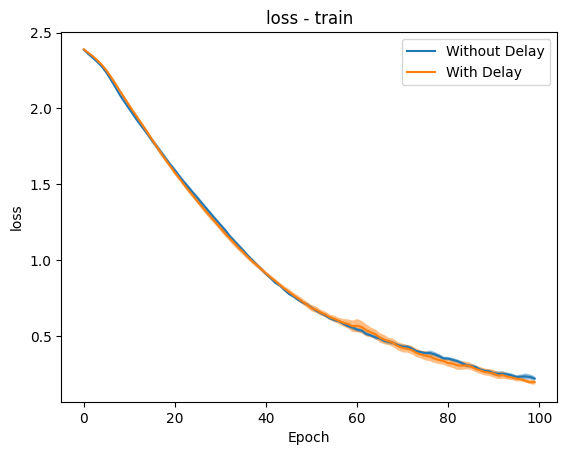

In [21]:
compare(results1, results2, 'loss', 'train')

### Test

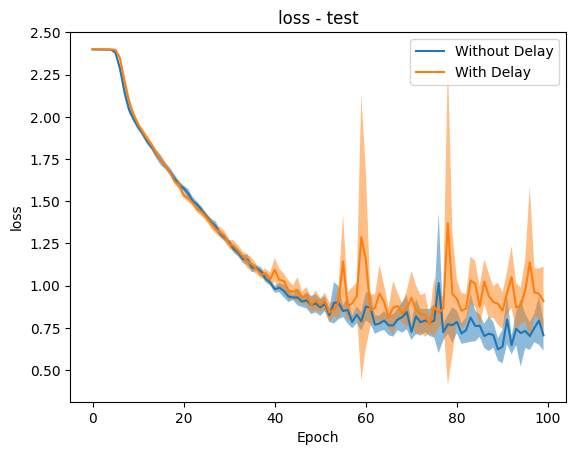

In [22]:
compare(results1, results2, 'loss', 'test')